### Sub/Upsampling trials


##### Question: expected p-value from X number of samples a valid way to account for the trial number false positives?


[27 aug 25 init]

In [1]:
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from config_plot import *
from generators import PoissonSpikeGenerator
from stats import ResponseCriteria
from utils_plots import plot_response

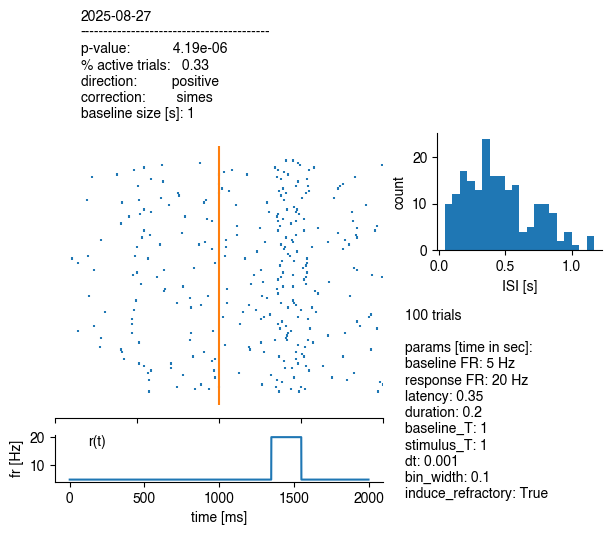

In [37]:
n_trials = 100

# simulation parameters
baseline_fr  = 5
response_fr  = 20
latency      = 0.350
duration     = 0.2
baseline_T   = 1
stimulus_T   = 1
dt           = 0.001
induce_refractory_period = True

# initialize generator with the variables
generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period
)

trial_activity = generator.generate(n_trials)

# analysis parameters
bin_width          = .1
proportion_active  = 1/3
direction          = "positive"
multiple_correction = "simes"
debug = False
use_baseline_mean_bin = True

stimulus_onset = 1
baseline_T_stat = 1

# initialize analysis object (using existing trial_activity, baseline_T, stimulus_T)
criteria = ResponseCriteria(
    trial_activity=trial_activity,
    baseline_T=baseline_T_stat,
    stimulus_T=stimulus_T,
    stimulus_onset=stimulus_onset,
    bin_width=bin_width,
    dt=dt,
    proportion_active=proportion_active,
    direction=direction,
    multiple_correction=multiple_correction,
    debug=debug,
)

plot_response(generator, criteria)

#### Checking how averaging across trial samplings affects the end value. 

100%|██████████| 100/100 [00:01<00:00, 63.44it/s]


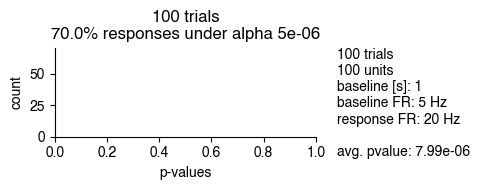

In [40]:
alpha_level = 5*(10**-6)

#############################################

n_units = 100
n_trials = 100

baseline_fr = 5
response_fr = 20

#############################################

# initialize generator with the variables
generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period
    )

# analysis parameters
bin_width          = .1
proportion_active  = 1/3
direction          = "positive"
multiple_correction = "simes"
stimulus_onset = 1
baseline_T_stat = 1

#############################################

pval_collection = []

for i in tqdm(range(n_units)):

    trial_activity = generator.generate(n_trials=n_trials)

    # initialize analysis object (using existing trial_activity, baseline_T, stimulus_T)
    criteria = ResponseCriteria(
        trial_activity=trial_activity,
        baseline_T=baseline_T_stat,
        stimulus_T=stimulus_T,
        bin_width=bin_width,
        dt=dt,
        proportion_active=proportion_active,
        direction=direction,
        multiple_correction=multiple_correction,
        stimulus_onset=stimulus_onset,
    )

    pval_collection.append(criteria.compute_pval())

pval_collection = np.array(pval_collection)

#############################################

fig, ax = plt.subplots(1,1, figsize=(5,2))

ax.hist(pval_collection, bins=30)
ax.set_xlim(0, 1)
ax.set_xlabel("p-values")
ax.set_ylabel("count")

s = (
    f"{n_trials} trials\n"
    f"{n_units} units\n"
    f"baseline [s]: {baseline_T_stat}\n"
    f"baseline FR: {baseline_fr} Hz\n"
    f"response FR: {response_fr} Hz\n\n"
    f"avg. pvalue: {np.mean(pval_collection):.3g}"
)

ax.text(
    1.08, 1, s,
    transform=ax.transAxes,   # use axes coords, not data coords
    ha="left", va="top"       # align text to the top-right
)

s = (
    f"{n_trials} trials\n"
    f"{round(sum(pval_collection <= alpha_level) / n_trials, 5)*100}% responses under alpha {alpha_level:.3g}"
)

ax.set_title(s)

sns.despine(ax=ax)
plt.tight_layout()
#plt.savefig(f"plots/{n_trials}trials_{n_units}units_b{baseline_fr}s{response_fr}_baselineSize{baseline_T_stat}.png", dpi=100,  bbox_inches='tight')
plt.show()

In [39]:
pval_collection

array([9.63157180e-07, 9.05950467e-09, 8.16591675e-05, 2.01410505e-08,
       1.24097796e-05, 1.16022946e-09, 2.82324579e-09, 1.13184792e-05,
       4.43814462e-06, 1.78260394e-06, 2.12961800e-07, 1.38046975e-06,
       7.57208615e-06, 1.01253638e-06, 3.32909508e-08, 8.86095717e-08,
       7.77099678e-07, 2.47371972e-07, 1.19576059e-05, 1.32181077e-06,
       2.51465046e-06, 9.22654062e-06, 1.56975276e-05, 2.03480607e-09,
       6.59991040e-06, 3.89090596e-06, 3.44439440e-06, 6.15264101e-05,
       8.92300100e-06, 3.18313373e-06, 1.05306691e-06, 6.84936249e-09,
       5.71454968e-05, 6.81514195e-07, 5.91396207e-08, 3.39212716e-07,
       4.13335421e-08, 1.20867827e-08, 3.62080373e-06, 3.70722626e-06,
       5.39940529e-07, 1.92226024e-06, 1.12624331e-06, 7.74663056e-05,
       2.93842944e-05, 1.26938505e-07, 4.85974984e-08, 1.56330604e-09,
       2.59288446e-09, 1.31134313e-05, 2.03736899e-05, 3.57411727e-07,
       1.53592459e-06, 3.47235635e-07, 1.17693868e-07, 5.85540782e-07,
      